<a href="https://colab.research.google.com/github/SamiraKheradmand/IASC-ASCE-Transformer-SHM/blob/main/IASC-ASCE-Transformer-SHM/notebooks/02_split_methods/block_random%20/BlochRandom_transformer_highpass_importance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [247]:
import os
import scipy.io as sio
from scipy.io.matlab._mio5_params import mat_struct
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

from pathlib import Path
import re
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [248]:
# ============================================================
# Permanent save folder in Google Drive
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

import os

SAVE_DIR = (
    "/content/drive/MyDrive/IASC_ASCE/"
    "results/sensor_importance/BlockRandom"
)

os.makedirs(SAVE_DIR, exist_ok=True)

print("Results will be saved in:")
print(SAVE_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Results will be saved in:
/content/drive/MyDrive/IASC_ASCE/results/sensor_importance/BlockRandom


In [249]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [250]:
!ls "/content/drive/My Drive/ASCE_IASC"

figures					random_window_split_seed42.csv
MAT_data				Results
processed_zero_mean			txt_all_15_sensors
random_block_assignment_45s_seed42.csv	txt_selected_sensors


In [251]:
from pathlib import Path

import numpy as np
import scipy.io as sio


# مسیر فایل‌ها
DATA_DIR = Path("/content/drive/MyDrive/ASCE_IASC/MAT_data")

# فقط 15 سنسور واقعی سازه
CHANNELS = [f"DA{i:02d}" for i in range(1, 16)]

# پیدا کردن فایل‌های 9 حالت سازه
mat_files = sorted(DATA_DIR.glob("shm*.mat"))

print("Folder exists:", DATA_DIR.exists())
print("Number of files:", len(mat_files))
print("Number of channels:", len(CHANNELS))


def load_ambient_file(file_path):
    """
    خواندن یک فایل Ambient از داده‌های IASC-ASCE
    """

    mat = sio.loadmat(file_path,squeeze_me=True,struct_as_record=False)

    dasy = mat["dasy"]
    dasy_dscr = mat["dasy_dscr"]
    fs = float(mat["fsdasy"])

    signals = []
    descriptions = []

    for i, channel in enumerate(CHANNELS, start=1):

        signal = np.asarray(getattr(dasy, channel)).reshape(-1)

        description_name = f"DAdscr{i:02d}"
        description = getattr(dasy_dscr, description_name)

        signals.append(signal)
        descriptions.append(description)

    # شکل خروجی:
    # (تعداد نمونه‌های زمانی، تعداد سنسورها)
    X_raw = np.column_stack(signals)

    return X_raw, fs, descriptions

Folder exists: True
Number of files: 9
Number of channels: 15


In [252]:
all_cases = {}

for file_path in mat_files:

    case_name = file_path.stem
    case_number = int(case_name[3:5])

    X_raw, fs, descriptions = load_ambient_file(file_path)

    all_cases[case_name] = {
        "X_raw": X_raw,
        "fs": fs,
        "channels": CHANNELS.copy(),
        "descriptions": descriptions,
        "case_number": case_number,
        "label": case_number - 1,
        "file_path": file_path
    }

    print(
        f"{case_name} | "
        f"shape: {X_raw.shape} | "
        f"fs: {fs} Hz | "
        f"label: {case_number - 1}"

    )
print( f"description: {pd.DataFrame(descriptions)}")

shm01a | shape: (60000, 15) | fs: 200.0 Hz | label: 0
shm02a | shape: (60000, 15) | fs: 200.0 Hz | label: 1
shm03a | shape: (60000, 15) | fs: 200.0 Hz | label: 2
shm04a | shape: (60000, 15) | fs: 200.0 Hz | label: 3
shm05a | shape: (60000, 15) | fs: 200.0 Hz | label: 4
shm06a | shape: (45568, 15) | fs: 200.0 Hz | label: 5
shm07a | shape: (180000, 15) | fs: 200.0 Hz | label: 6
shm08a | shape: (180000, 15) | fs: 200.0 Hz | label: 7
shm09a | shape: (180000, 15) | fs: 200.0 Hz | label: 8
description:                                                0
0   Base West side - EPI sensor X direction (N+)
1      Base Center - EPI sensor Y direction (W+)
2   Base East side - EPI sensor X direction (N+)
3    1st Floor - N/S EPI Sensor at West end (N+)
4      1st Floor - E/W FBA Sensor at Center (W+)
5    1st Floor - N/S FBA Sensor at East end (N+)
6    2nd Floor - N/S FBA Sensor at West end (N+)
7      2nd Floor - E/W EPI Sensor at Center (W+)
8    2nd Floor - N/S EPI Sensor at East end (N+)
9    3rd

In [253]:
print(all_cases["shm01a"]["X_raw"].shape)
print(all_cases["shm01a"]["channels"])


(60000, 15)
['DA01', 'DA02', 'DA03', 'DA04', 'DA05', 'DA06', 'DA07', 'DA08', 'DA09', 'DA10', 'DA11', 'DA12', 'DA13', 'DA14', 'DA15']


In [254]:
# ============================================================
#  Step 2: Random Block Split settings
# ============================================================

import pandas as pd
from scipy.signal import butter, sosfiltfilt
import random


# ----------------------------
# Reproducibility
# ----------------------------
SPLIT_SEED = 42
MODEL_SEED = 7

def set_seed(seed):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Reproducibility for CUDA
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # Warn if a nondeterministic operation is used
    torch.use_deterministic_algorithms(True,warn_only=True)

set_seed(MODEL_SEED)



# ----------------------------
# Block split settings
# ----------------------------
BLOCK_SEC = 45
TRAIN_RATIO = 0.60
VAL_RATIO = 0.20

# GAP_SEC = 0
EDGE_SEC = 2


# ----------------------------
# High-pass filter settings
# ----------------------------
USE_HIGHPASS = True
CUTOFF = 0.1
ORDER = 2


def highpass_filter(X, fs):

    """
    Apply a Butterworth high-pass filter to all sensor channels.
    X shape:(samples, sensors)
    """

    sos = butter(N=ORDER, Wn=CUTOFF,btype="highpass",fs=fs,output="sos")
    X_filtered = sosfiltfilt(sos,X,axis=0)

    return X_filtered

In [255]:
# ============================================================
# Step 4: Create fixed random block assignments
# ============================================================

assignment_rows = []
block_summary_rows = []

for case_name in sorted(all_cases.keys()):

    X_raw = all_cases[case_name]["X_raw"]
    fs = all_cases[case_name]["fs"]

    n_samples = len(X_raw)
    block_size = int(BLOCK_SEC * fs)

    # فقط بلوک‌های کامل
    number_of_blocks = (len(X_raw) // block_size)

    if number_of_blocks < 5:
        raise ValueError(f"{case_name}: fewer than five complete blocks.")

    used_samples = (number_of_blocks * block_size)
    unused_samples = (n_samples - used_samples )

    # ----------------------------
    # Number of blocks per split
    # ----------------------------
    number_of_train_blocks = int(round(TRAIN_RATIO * number_of_blocks))
    number_of_val_blocks = int(round(VAL_RATIO * number_of_blocks))
    number_of_test_blocks = (number_of_blocks- number_of_train_blocks- number_of_val_blocks)

    # حداقل یک بلوک برای هر Split
    if number_of_train_blocks < 1: number_of_train_blocks = 1
    if number_of_val_blocks < 1: number_of_val_blocks = 1

    # ----------------------------
    # Random block order
    # A separate deterministic seed per case
    # ----------------------------
    scenario_number = int(case_name[3:5])
    case_generator = np.random.default_rng(SPLIT_SEED + scenario_number)
    shuffled_ids = (case_generator.permutation(number_of_blocks))

    train_ids = set(shuffled_ids[:number_of_train_blocks])
    val_ids = set(shuffled_ids[number_of_train_blocks:number_of_train_blocks+ number_of_val_blocks])
    test_ids = set(shuffled_ids[number_of_train_blocks+ number_of_val_blocks:])

    # ----------------------------
    # Save block assignments
    # ----------------------------
    for block_id in range(number_of_blocks):

        start_sample = (block_id * block_size)
        end_sample = (start_sample + block_size)

        if block_id in train_ids:
            split_name = "train"

        elif block_id in val_ids:
            split_name = "validation"

        elif block_id in test_ids:
            split_name = "test"

        else:
            raise RuntimeError("Block assignment failed.")

        start_sample = block_id * block_size
        end_sample = start_sample + block_size

        assignment_rows.append({
            "case": case_name,
            "block_id": block_id,
            "start_sample": start_sample,
            "end_sample": end_sample,
            "start_sec": start_sample / fs,
            "end_sec": end_sample / fs,
            "split": split_name
        })
    used_samples = number_of_blocks * block_size
    unused_samples = n_samples - used_samples

    block_summary_rows.append({
        "case": case_name,
        "total_blocks": number_of_blocks,
        "train_blocks": number_of_train_blocks,
        "validation_blocks": number_of_val_blocks,
        "test_blocks": number_of_test_blocks,
        "unused_seconds": unused_samples / fs
    })

In [256]:
block_assignment_df = pd.DataFrame(assignment_rows)
display(block_assignment_df.head(20))

block_summary_df = pd.DataFrame(block_summary_rows)
display(block_summary_df)

,case,block_id,start_sample,end_sample,start_sec,end_sec,split
0,shm01a,0,0,9000,0.0,45.0,validation
1,shm01a,1,9000,18000,45.0,90.0,train
2,shm01a,2,18000,27000,90.0,135.0,train
3,shm01a,3,27000,36000,135.0,180.0,test
4,shm01a,4,36000,45000,180.0,225.0,train
5,shm01a,5,45000,54000,225.0,270.0,train
6,shm02a,0,0,9000,0.0,45.0,train
7,shm02a,1,9000,18000,45.0,90.0,test
8,shm02a,2,18000,27000,90.0,135.0,train
9,shm02a,3,27000,36000,135.0,180.0,train


,case,total_blocks,train_blocks,validation_blocks,test_blocks,unused_seconds
0,shm01a,6,4,1,1,30.00
1,shm02a,6,4,1,1,30.00
2,shm03a,6,4,1,1,30.00
3,shm04a,6,4,1,1,30.00
4,shm05a,6,4,1,1,30.00
5,shm06a,5,3,1,1,2.84
6,shm07a,20,12,4,4,0.00
7,shm08a,20,12,4,4,0.00
8,shm09a,20,12,4,4,0.00


In [257]:
block_count_df = (block_assignment_df.groupby(["case", "split"]).size().unstack(fill_value=0))

display(block_count_df)

split,test,train,validation
case,,,
shm01a,1,4,1
shm02a,1,4,1
shm03a,1,4,1
shm04a,1,4,1
shm05a,1,4,1
shm06a,1,3,1
shm07a,4,12,4
shm08a,4,12,4
shm09a,4,12,4


In [258]:
BLOCK_ASSIGNMENT_PATH = (
    "/content/drive/MyDrive/ASCE_IASC/"
    f"random_block_assignment_45s_seed{SPLIT_SEED}.csv")

block_assignment_df.to_csv(BLOCK_ASSIGNMENT_PATH,index=False)
print("Block assignment saved:",BLOCK_ASSIGNMENT_PATH)

Block assignment saved: /content/drive/MyDrive/ASCE_IASC/random_block_assignment_45s_seed42.csv


In [259]:
# block_assignment_df = pd.read_csv(BLOCK_ASSIGNMENT_PATH)

In [260]:
# ============================================================
# Build Train, Validation and Test block lists
# ============================================================

train_blocks = []
val_blocks = []
test_blocks = []


for _, row in block_assignment_df.iterrows():

    case_name = row["case"]
    block_id = int(row["block_id"])
    split_name = row["split"]

    start_sample = int(row["start_sample"])
    end_sample = int(row["end_sample"])

    X_raw = all_cases[case_name]["X_raw"]
    fs = all_cases[case_name]["fs"]
    edge_size = int(EDGE_SEC * fs)

    # ----------------------------
    # Extract one raw block
    # ----------------------------
    X_block = X_raw[start_sample:end_sample]

    # ----------------------------
    # Optional high-pass filter
    # ----------------------------
    if USE_HIGHPASS:
        X_block = highpass_filter(X_block,fs)

    else:
        X_block = X_block.copy()

    # ----------------------------
    # Matched edge removal
    # ----------------------------
    X_block = X_block[edge_size:-edge_size]

    block_record = {
        "case": case_name,
        "block_id": block_id,
        "data": X_block
    }

    if split_name == "train":
        train_blocks.append(block_record)

    elif split_name == "validation":
        val_blocks.append(block_record)

    elif split_name == "test":
        test_blocks.append(block_record)

In [261]:
print("Train blocks:", len(train_blocks))
print("Validation blocks:", len(val_blocks))
print("Test blocks:", len(test_blocks))

Train blocks: 59
Validation blocks: 18
Test blocks: 18


In [262]:
print("Example block shape:",
    train_blocks[0]["data"].shape)
# (7000, 15)

Example block shape: (8200, 15)


In [263]:
# ============================================================
# Step 3: Select sensor channels
# ============================================================

# selected_sensor_indices = [8, 11, 13, 14]  # DA09, DA12, DA14, DA15
# selected_sensor_indices = [0,3]
selected_sensor_indices = [3,4,5,6,7,8,9,10,11,12,13,14]

selected_sensor_names = [CHANNELS[i] for i in selected_sensor_indices]



In [264]:
def select_sensors(block_list):
    """
    Select sensor columns from every block.
    """

    selected_list = []

    for block in block_list:

        selected_block = {"case": block["case"],
                      "block_id": block["block_id"],
                          "data": block["data"][:,selected_sensor_indices]}

        selected_list.append(selected_block)

    return selected_list

In [265]:
train_selected = select_sensors(train_blocks)
val_selected = select_sensors(val_blocks)
test_selected = select_sensors(test_blocks)

In [266]:
print(
    "Selected Train block shape:",
    train_selected[0]["data"].shape
)

Selected Train block shape: (8200, 12)


In [267]:
# ============================================================
# Step 7: Global train-based normalization
# One mean and standard deviation for each selected sensor
# ============================================================

EPS = 1e-8

train_concat = np.concatenate(
    [ block["data"] for block in train_selected], axis=0)


print("Combined Train shape:",train_concat.shape)

Combined Train shape: (483800, 12)


In [268]:
train_mean = train_concat.mean(axis=0, keepdims=True, dtype=np.float64)
train_std = train_concat.std( axis=0,keepdims=True,dtype=np.float64)

# Prevent division by zero
train_std_safe = np.where(train_std < EPS,1.0,train_std)

print("Train mean shape:", train_mean.shape)
print("Train std shape:", train_std_safe.shape)

Train mean shape: (1, 12)
Train std shape: (1, 12)


In [269]:
def normalize_blocks(block_list):

    normalized_blocks = []

    for block in block_list:

        X_normalized = ((block["data"]-train_mean)/train_std_safe).astype(np.float32)

        normalized_block = {
            "case": block["case"],
            "block_id": block["block_id"],
            "data": X_normalized
        }

        normalized_blocks.append(normalized_block)

    return normalized_blocks

In [270]:
train_norm = normalize_blocks(train_selected)
val_norm = normalize_blocks(val_selected)
test_norm = normalize_blocks(test_selected)

print("Normalization completed.")

Normalization completed.


In [271]:
train_norm_concat = np.concatenate(
    [ block["data"] for block in train_norm],axis=0)


print("Train mean after normalization:",
    np.round(train_norm_concat.mean(axis=0),5))

print("Train std after normalization:",
    np.round(train_norm_concat.std(axis=0),5))

Train mean after normalization: [ 0.  0.  0.  0.  0.  0.  0.  0. -0.  0. -0. -0.]
Train std after normalization: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [272]:
# ============================================================
# Step 5: Create non-overlapping time windows
# ============================================================

WINDOW_SIZE = 512
STEP_SIZE = 512

FS_DASY = 200

print("Window size:", WINDOW_SIZE, "samples")
print("Window duration:", WINDOW_SIZE / FS_DASY, "seconds")
print("Step size:", STEP_SIZE, "samples")
print("Step duration:", STEP_SIZE / FS_DASY, "seconds")

Window size: 512 samples
Window duration: 2.56 seconds
Step size: 512 samples
Step duration: 2.56 seconds


In [273]:
def make_windows(split_data):
    """
    Convert continuous signals of each scenario into fixed-length windows.
    Input:
        split_data[case_name]
        shape = (samples, selected_sensors)

    Output:
        X_windows shape = (number_of_windows, window_size, selected_sensors)
        y_labels shape = (number_of_windows,)
    """

    all_windows = []
    all_labels = []
    meta_rows = []

    for block in split_data:

        case_name = block["case"]
        block_id = block["block_id"]
        X = block["data"]

        scenario_number = int(case_name[3:5])
        label = scenario_number - 1
        window_number = 0

        for start in range(0,len(X) - WINDOW_SIZE + 1,STEP_SIZE):

            end = start + WINDOW_SIZE
            window = X[start:end,:]
            all_windows.append(window)
            all_labels.append(label)

            meta_rows.append({
                "case": case_name,
                "scenario": scenario_number,
                "label": label,
                "block_id": block_id,
                "window": window_number,
                "start_sample_in_block": start,
                "end_sample_in_block": end})

            window_number += 1

    if len(all_windows) == 0:
       raise ValueError("No windows were created.")

    X_windows = np.stack(all_windows,axis=0).astype(np.float32)
    y_labels = np.array(all_labels,dtype=np.int64)
    meta_df = pd.DataFrame(meta_rows)

    return X_windows, y_labels, meta_df

In [274]:
X_train, y_train, train_meta_df = make_windows(train_norm)
X_val, y_val, val_meta_df = make_windows(val_norm)
X_test, y_test, test_meta_df = make_windows(test_norm)

In [275]:
print("Train windows per case:")

display(
    train_meta_df
    .groupby("case")
    .size()
    .reset_index(name="windows")
)


print("Validation windows per case:")

display(
    val_meta_df
    .groupby("case")
    .size()
    .reset_index(name="windows")
)


print("Test windows per case:")

display(
    test_meta_df
    .groupby("case")
    .size()
    .reset_index(name="windows")
)

Train windows per case:


,case,windows
0,shm01a,64
1,shm02a,64
2,shm03a,64
3,shm04a,64
4,shm05a,64
5,shm06a,48
6,shm07a,192
7,shm08a,192
8,shm09a,192


Validation windows per case:


,case,windows
0,shm01a,16
1,shm02a,16
2,shm03a,16
3,shm04a,16
4,shm05a,16
5,shm06a,16
6,shm07a,64
7,shm08a,64
8,shm09a,64


Test windows per case:


,case,windows
0,shm01a,16
1,shm02a,16
2,shm03a,16
3,shm04a,16
4,shm05a,16
5,shm06a,16
6,shm07a,64
7,shm08a,64
8,shm09a,64


In [276]:
import numpy as np
import torch

from torch.utils.data import TensorDataset, DataLoader


# ----------------------------
# بررسی داده‌ها قبل از Tensor
# ----------------------------
print("X_train shape:", X_train.shape)
print("X_val shape:  ", X_val.shape)
print("X_test shape: ", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_val shape:  ", y_val.shape)
print("y_test shape: ", y_test.shape)


# تعداد داده و برچسب باید برابر باشد
assert len(X_train) == len(y_train)
assert len(X_val) == len(y_val)
assert len(X_test) == len(y_test)

# بررسی NaN و Inf
assert np.isfinite(X_train).all(), "X_train contains NaN or Inf."
assert np.isfinite(X_val).all(), "X_val contains NaN or Inf."
assert np.isfinite(X_test).all(), "X_test contains NaN or Inf."

print("Data check completed.")

X_train shape: (944, 512, 12)
X_val shape:   (288, 512, 12)
X_test shape:  (288, 512, 12)
y_train shape: (944,)
y_val shape:   (288,)
y_test shape:  (288,)
Data check completed.


In [277]:
# ============================================================
# Step 6: Convert arrays to PyTorch tensors
# ============================================================

import random
import numpy as np
import torch

from torch.utils.data import TensorDataset, DataLoader


set_seed(MODEL_SEED)

# Inputs must be float32
X_train_tensor = torch.from_numpy(X_train.astype(np.float32, copy=False))
X_val_tensor = torch.from_numpy(X_val.astype(np.float32, copy=False))
X_test_tensor = torch.from_numpy(X_test.astype(np.float32, copy=False))


# Labels for CrossEntropyLoss must be int64
y_train_tensor = torch.from_numpy(y_train.astype(np.int64, copy=False))
y_val_tensor = torch.from_numpy(y_val.astype(np.int64, copy=False))
y_test_tensor = torch.from_numpy(y_test.astype(np.int64, copy=False))


print("\nTensor shapes:")
print("X_train_tensor:", X_train_tensor.shape)
print("y_train_tensor:", y_train_tensor.shape)

print("X_val_tensor:", X_val_tensor.shape)
print("y_val_tensor:", y_val_tensor.shape)

print("X_test_tensor:", X_test_tensor.shape)
print("y_test_tensor:", y_test_tensor.shape)


Tensor shapes:
X_train_tensor: torch.Size([944, 512, 12])
y_train_tensor: torch.Size([944])
X_val_tensor: torch.Size([288, 512, 12])
y_val_tensor: torch.Size([288])
X_test_tensor: torch.Size([288, 512, 12])
y_test_tensor: torch.Size([288])


In [278]:
# ============================================================
# Create Dataset and DataLoader
# ============================================================

train_dataset = TensorDataset(X_train_tensor,y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor,y_val_tensor)
test_dataset  = TensorDataset(X_test_tensor,y_test_tensor)

BATCH_SIZE = 64

# برای تکرارپذیری Shuffle داده‌های Train
loader_generator = torch.Generator()
loader_generator.manual_seed(MODEL_SEED)


train_loader = DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True,generator=loader_generator)
val_loader   = DataLoader(val_dataset,batch_size=BATCH_SIZE,shuffle=False)
test_loader  = DataLoader(test_dataset,batch_size=BATCH_SIZE,shuffle=False)

In [279]:
print("Number of train samples:", len(train_dataset))
print("Number of val samples:  ", len(val_dataset))
print("Number of test samples: ", len(test_dataset))

print("\nNumber of train batches:", len(train_loader))
print("Number of val batches:  ", len(val_loader))
print("Number of test batches: ", len(test_loader))


X_batch, y_batch = next(iter(train_loader))

print("\nOne train batch:")
print("X_batch shape:", X_batch.shape)
print("y_batch shape:", y_batch.shape)
print("First 10 labels:", y_batch[:10])

Number of train samples: 944
Number of val samples:   288
Number of test samples:  288

Number of train batches: 15
Number of val batches:   5
Number of test batches:  5

One train batch:
X_batch shape: torch.Size([64, 512, 12])
y_batch shape: torch.Size([64])
First 10 labels: tensor([3, 8, 8, 3, 8, 4, 6, 6, 8, 5])


In [280]:
# ============================================================
# Step 7: Define raw time-series Transformer
# Input shape: (batch, time, sensors)
# ============================================================

import torch.nn as nn
from sklearn.metrics import accuracy_score, f1_score

# ----------------------------
# Device
# ----------------------------
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)


# ----------------------------
# Learnable positional encoding
# ----------------------------
class LearnablePositionalEncoding(nn.Module):

    def __init__(self, seq_len, d_model):
        super().__init__()
        self.position = nn.Parameter(torch.zeros(1, seq_len, d_model))
        nn.init.trunc_normal_(self.position,std=0.02)

    def forward(self, x):
        seq_len = x.shape[1]
        return x + self.position[:, :seq_len, :]

Device: cuda


In [281]:
# ============================================================
# Step 7: Define raw time-series Transformer
# Input shape: (batch, time, sensors)
# ============================================================

import torch.nn as nn

# --- Added these definitions to ensure the model parameters are defined ---
NUM_CLASSES = 9
SEQ_LEN = WINDOW_SIZE
INPUT_DIM = X_train_tensor.shape[2]
D_MODEL = 64
NUM_HEADS = 8
NUM_LAYERS = 2
DIM_FEEDFORWARD = 64
DROPOUT = 0.10
# --- End of added definitions ---

class TransformerTimeSeriesClassifier(nn.Module):
    def __init__(
        self,
        input_dim,
        seq_len,
        num_classes,
        d_model=64,
        num_heads=8,
        num_layers=2,
        dim_feedforward=64,
        dropout=0.10
    ):
        super().__init__()

        self.seq_len = seq_len
        self.d_model = d_model

        self.input_projection = nn.Linear(input_dim, d_model)
        self.pos_embedding = nn.Parameter(torch.zeros(1, seq_len, d_model))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=num_heads,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation="relu",
            batch_first=True,
            norm_first=True
        )

        self.transformer_encoder = nn.TransformerEncoder(encoder_layer,num_layers=num_layers)
        self.final_norm = nn.LayerNorm(d_model)
        self.classifier = nn.Linear(d_model,num_classes)
        self._init_weights()

    def _init_weights(self):
        nn.init.normal_(self.pos_embedding, mean=0.0, std=0.02)

    def forward(self, x):
        # x shape: (batch, time, channels)

        x = self.input_projection(x)
        x = x + self.pos_embedding[:, :x.size(1), :]
        x = self.transformer_encoder(x)
        x = self.final_norm(x)
        # Mean pooling over time
        x = x.mean(dim=1)
        logits = self.classifier(x)
        return logits
set_seed(MODEL_SEED)
model = TransformerTimeSeriesClassifier(
    input_dim=INPUT_DIM,
    seq_len=SEQ_LEN,
    num_classes=NUM_CLASSES,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    dim_feedforward=DIM_FEEDFORWARD,
    dropout=DROPOUT
).to(device)

print(model)

# ----------------------------
# Count trainable parameters
# ----------------------------
def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("\nTrainable parameters:", count_trainable_parameters(model))


# ----------------------------
# Check one forward pass
# ----------------------------
for xb, yb in train_loader:
    xb = xb.to(device)

    logits = model(xb)

    print("\nInput batch shape:", xb.shape)
    print("Output logits shape:", logits.shape)

    break

TransformerTimeSeriesClassifier(
  (input_projection): Linear(in_features=12, out_features=64, bias=True)
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=64, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=64, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (final_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (classifier): Linear(in_features=64, out_features=9, bias=True)
)

Trainable parameters: 84745

Input batch shape:

/tmp/ipykernel_1803/2716909781.py:49: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer_encoder = nn.TransformerEncoder(encoder_layer,num_layers=num_layers)


In [282]:
# ============================================================
# Step 8: Loss function and optimizer
# ============================================================

class_counts = torch.bincount(y_train_tensor, minlength=NUM_CLASSES).float()
if torch.any(class_counts == 0):
    raise ValueError("At least one class has no training samples.")

class_weights = (len(y_train_tensor) / (NUM_CLASSES * class_counts))
class_weights = class_weights.to(device)

print("Class counts and weights:")

for class_id in range(NUM_CLASSES):

    print(
        f"Scenario {class_id + 1} | "
        f"count: {int(class_counts[class_id])} | "
        f"weight: {class_weights[class_id].item():.4f}"
    )

Class counts and weights:
Scenario 1 | count: 64 | weight: 1.6389
Scenario 2 | count: 64 | weight: 1.6389
Scenario 3 | count: 64 | weight: 1.6389
Scenario 4 | count: 64 | weight: 1.6389
Scenario 5 | count: 64 | weight: 1.6389
Scenario 6 | count: 48 | weight: 2.1852
Scenario 7 | count: 192 | weight: 0.5463
Scenario 8 | count: 192 | weight: 0.5463
Scenario 9 | count: 192 | weight: 0.5463


In [283]:
LEARNING_RATE = 2e-4
WEIGHT_DECAY = 1e-4
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(),lr=LEARNING_RATE,weight_decay=WEIGHT_DECAY)

print("Loss function:", criterion)
print("Optimizer:", optimizer.__class__.__name__)
print("Learning rate:", LEARNING_RATE)

Loss function: CrossEntropyLoss()
Optimizer: AdamW
Learning rate: 0.0002


In [284]:
# ============================================================
# Step 9: Train Transformer
# Best model selection based on Validation Macro-F1
# ============================================================

from sklearn.metrics import accuracy_score, f1_score
import copy
import torch

NUM_EPOCHS = 100
PATIENCE = 20
GRAD_CLIP = 1.0
MIN_DELTA = 1e-4

LABELS_ORDER = np.arange(NUM_CLASSES)

transformer_history = {
    "epoch": [],
    "train_loss": [],
    "train_acc": [],
    "train_macro_f1": [],
    "val_loss": [],
    "val_acc": [],
    "val_macro_f1": [],
}

best_val_macro_f1 = -1.0
best_epoch = 0
best_model_state = None
epochs_without_improvement = 0


def run_one_epoch_transformer(model, data_loader, criterion, optimizer=None, device="cpu"):
    """
    If optimizer is given: training mode
    If optimizer is None: evaluation mode
    """

    is_training = optimizer is not None

    if is_training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    for xb, yb in data_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        if is_training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_training):
            logits = model(xb)
            loss = criterion(logits, yb)

            if is_training:
                loss.backward()

                # Gradient clipping helps Transformer training stability
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)

                optimizer.step()

        total_loss += loss.item() * xb.size(0)
        preds = torch.argmax(logits, dim=1)
        all_preds.append(preds.detach().cpu())
        all_labels.append(yb.detach().cpu())

    avg_loss = total_loss / len(data_loader.dataset)
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    return avg_loss, acc, macro_f1


for epoch in range(1, NUM_EPOCHS + 1):

    train_loss, train_acc, train_macro_f1 = run_one_epoch_transformer(
        model=model,
        data_loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    val_loss, val_acc, val_macro_f1 = run_one_epoch_transformer(
        model=model,
        data_loader=val_loader,
        criterion=criterion,
        optimizer=None,
        device=device
    )

    transformer_history["epoch"].append(epoch)
    transformer_history["train_loss"].append(train_loss)
    transformer_history["train_acc"].append(train_acc)
    transformer_history["train_macro_f1"].append(train_macro_f1)
    transformer_history["val_loss"].append(val_loss)
    transformer_history["val_acc"].append(val_acc)
    transformer_history["val_macro_f1"].append(val_macro_f1)

    # Save best model based on validation Macro-F1
    if val_macro_f1 > best_val_macro_f1 + MIN_DELTA:
        best_val_macro_f1 = val_macro_f1
        best_epoch = epoch
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epoch == 1 or epoch % 5 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Train Macro-F1: {train_macro_f1:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f} | "
            f"Val Macro-F1: {val_macro_f1:.4f}"
        )

    # Early stopping
    if epochs_without_improvement >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}.")
        break



Epoch 001 | Train Loss: 2.0949 | Train Acc: 0.1811 | Train Macro-F1: 0.0716 | Val Loss: 1.9432 | Val Acc: 0.0938 | Val Macro-F1: 0.0545
Epoch 005 | Train Loss: 1.1335 | Train Acc: 0.7871 | Train Macro-F1: 0.6593 | Val Loss: 0.9806 | Val Acc: 0.8021 | Val Macro-F1: 0.6679
Epoch 010 | Train Loss: 0.4949 | Train Acc: 0.9746 | Train Macro-F1: 0.9829 | Val Loss: 0.4020 | Val Acc: 0.9653 | Val Macro-F1: 0.9694
Epoch 015 | Train Loss: 0.1412 | Train Acc: 0.9947 | Train Macro-F1: 0.9971 | Val Loss: 0.1393 | Val Acc: 0.9757 | Val Macro-F1: 0.9747
Epoch 020 | Train Loss: 0.0618 | Train Acc: 0.9968 | Train Macro-F1: 0.9983 | Val Loss: 0.0804 | Val Acc: 0.9826 | Val Macro-F1: 0.9806
Epoch 025 | Train Loss: 0.0370 | Train Acc: 0.9979 | Train Macro-F1: 0.9988 | Val Loss: 0.0554 | Val Acc: 0.9896 | Val Macro-F1: 0.9841
Epoch 030 | Train Loss: 0.0255 | Train Acc: 0.9989 | Train Macro-F1: 0.9994 | Val Loss: 0.0458 | Val Acc: 0.9896 | Val Macro-F1: 0.9866
Epoch 035 | Train Loss: 0.0188 | Train Acc: 1.00

In [285]:
if best_model_state is None:
    raise RuntimeError("No best model was saved.")

model.load_state_dict(best_model_state)

print("\nTraining finished.")
print("Best epoch:",best_epoch)
print("Best validation Macro-F1:",best_val_macro_f1)


Training finished.
Best epoch: 30
Best validation Macro-F1: 0.9866280457014756


In [286]:
# ============================================================
# Final evaluation control
# ============================================================

# Keep False during development/tuning.
# Set True only for final test evaluation.
RUN_TEST = False

In [287]:
# ============================================================
# Final evaluation
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)

import pandas as pd
import torch


train_eval_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


def predict_with_model_transformer(
    model,
    data_loader,
    device="cpu"
):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for xb, yb in data_loader:

            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            preds = torch.argmax(logits,dim=1)
            all_preds.append(preds.cpu())
            all_labels.append(yb.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    return all_labels, all_preds


def final_evaluate_transformer(
    model,
    data_loader,
    split_name,
    device="cpu"
):

    y_true, y_pred = predict_with_model_transformer(
        model=model,
        data_loader=data_loader,
        device=device
    )

    acc = accuracy_score(
        y_true,
        y_pred
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    weighted_f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    print(f"\n===== {split_name} =====")
    print(f"Accuracy:    {acc:.4f}")
    print(f"Macro-F1:    {macro_f1:.4f}")
    print(f"Weighted-F1: {weighted_f1:.4f}")

    return {
        "split": split_name,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "y_true": y_true,
        "y_pred": y_pred
    }

In [288]:
model.eval()

transformer_train_results = final_evaluate_transformer(
    model,
    train_eval_loader,
    "TRAIN",
    device=device
)

transformer_val_results = final_evaluate_transformer(
    model,
    val_loader,
    "VALIDATION",
    device=device
)


===== TRAIN =====
Accuracy:    0.9989
Macro-F1:    0.9994
Weighted-F1: 0.9989

===== VALIDATION =====
Accuracy:    0.9896
Macro-F1:    0.9866
Weighted-F1: 0.9894


In [289]:
transformer_test_results = None

if RUN_TEST:

    transformer_test_results = final_evaluate_transformer(
        model,
        test_loader,
        "TEST",
        device=device
    )

else:

    print("\nTest evaluation skipped.")


Test evaluation skipped.


In [290]:
summary_rows = [
    {
        "model": "Raw Transformer",
        "preprocessing":
            "Butterworth high-pass + Train-based normalization",
        "selected_sensors":
            len(selected_sensor_names),
        "split":
            transformer_train_results["split"],
        "accuracy":
            transformer_train_results["accuracy"],
        "macro_f1":
            transformer_train_results["macro_f1"],
        "weighted_f1":
            transformer_train_results["weighted_f1"]
    },

    {
        "model": "Raw Transformer",
        "preprocessing":
            "Butterworth high-pass + Train-based normalization",
        "selected_sensors":
            len(selected_sensor_names),
        "split":
            transformer_val_results["split"],
        "accuracy":
            transformer_val_results["accuracy"],
        "macro_f1":
            transformer_val_results["macro_f1"],
        "weighted_f1":
            transformer_val_results["weighted_f1"]
    }
]

In [291]:
if RUN_TEST:

    summary_rows.append(
        {
            "model": "Raw Transformer",
            "preprocessing":
                "Butterworth high-pass + Train-based normalization",
            "selected_sensors":
                len(selected_sensor_names),
            "split":
                transformer_test_results["split"],
            "accuracy":
                transformer_test_results["accuracy"],
            "macro_f1":
                transformer_test_results["macro_f1"],
            "weighted_f1":
                transformer_test_results["weighted_f1"]
        }
    )

In [292]:
transformer_summary_results = pd.DataFrame(
    summary_rows
)

display(
    transformer_summary_results
)

,model,preprocessing,selected_sensors,split,accuracy,macro_f1,weighted_f1
0,Raw Transformer,Butterworth high-pass + Train-based normalization,12,TRAIN,0.998941,0.999421,0.998941
1,Raw Transformer,Butterworth high-pass + Train-based normalization,12,VALIDATION,0.989583,0.986628,0.989418


In [293]:
# ============================================================
# Step 11: Test confusion matrix
# ============================================================


if RUN_TEST:

    y_true_test = (
        transformer_test_results["y_true"]
    )

    y_pred_test = (
        transformer_test_results["y_pred"]
    )

    cm_transformer_test = confusion_matrix(
        y_true_test,
        y_pred_test,
        labels=np.arange(NUM_CLASSES)
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_transformer_test,
        display_labels=[
            f"S{i+1}"
            for i in range(NUM_CLASSES)
        ]
    )

    disp.plot(
        values_format="d",
        cmap="Blues",
        colorbar=False
    )

    plt.title(
        "Test Confusion Matrix"
    )

    plt.grid(False)
    plt.show()

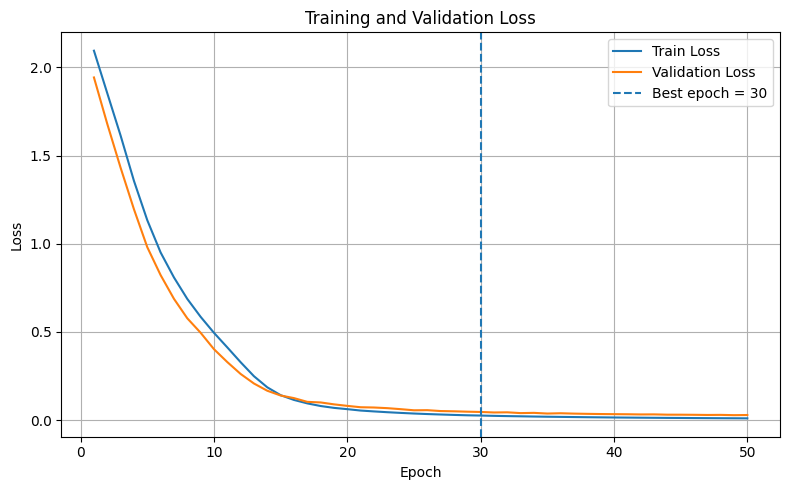

In [294]:
# ============================================================
# Step 12: Training curves
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    transformer_history["epoch"],
    transformer_history["train_loss"],
    label="Train Loss"
)

plt.plot(
    transformer_history["epoch"],
    transformer_history["val_loss"],
    label="Validation Loss"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best epoch = {best_epoch}"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

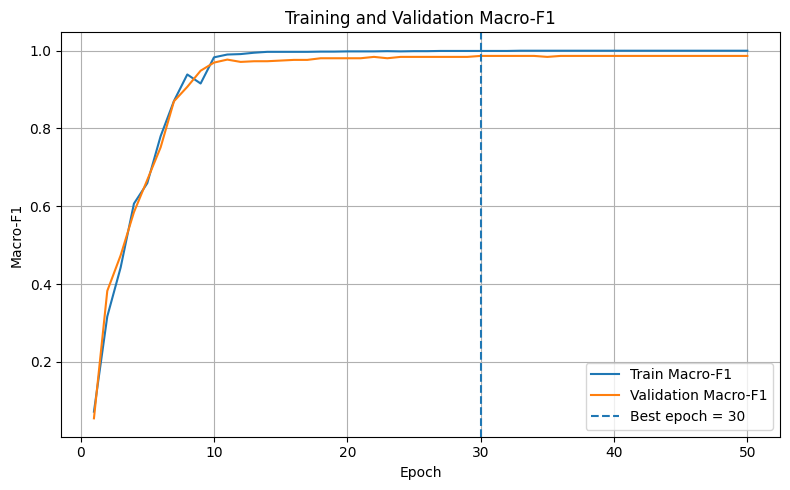

In [295]:
plt.figure(figsize=(8, 5))

plt.plot(
    transformer_history["epoch"],
    transformer_history["train_macro_f1"],
    label="Train Macro-F1"
)

plt.plot(
    transformer_history["epoch"],
    transformer_history["val_macro_f1"],
    label="Validation Macro-F1"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best epoch = {best_epoch}"
)

plt.xlabel("Epoch")
plt.ylabel("Macro-F1")
plt.title("Training and Validation Macro-F1")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Sensor Permutation Importance
## Phase 1 - Block Random Split - Validation Set

Global grouped sensor permutation importance.

Each complete sensor waveform (512 time samples) is permuted
across validation windows while the other sensors remain unchanged.

Primary metric:
Importance = Baseline Macro-F1 - Permuted Macro-F1

The test set is not used in this phase.

In [296]:
# ============================================================
# Sensor Permutation Importance - Basic checks
# ============================================================

print("Validation shape:", X_val.shape)
print("Validation labels:", y_val.shape)

print("\nSensor order:")
for i, sensor in enumerate(selected_sensor_names):
    print(i, sensor)

print(
    "\nBaseline Validation Macro-F1:",
    transformer_val_results["macro_f1"]
)

# Basic checks
assert X_val.ndim == 3
assert X_val.shape[1] == WINDOW_SIZE
assert X_val.shape[2] == len(selected_sensor_names)
assert len(X_val) == len(y_val)

print("\nBasic checks passed.")

Validation shape: (288, 512, 12)
Validation labels: (288,)

Sensor order:
0 DA04
1 DA05
2 DA06
3 DA07
4 DA08
5 DA09
6 DA10
7 DA11
8 DA12
9 DA13
10 DA14
11 DA15

Baseline Validation Macro-F1: 0.9866280457014756

Basic checks passed.


In [297]:
# ============================================================
# Step 3 - Test one grouped sensor permutation
# ============================================================

PERMUTATION_SEED = 1001

sensor_name = "DA04"
sensor_idx = selected_sensor_names.index(sensor_name)

rng = np.random.default_rng(PERMUTATION_SEED)

# Random order of validation windows
perm_idx = rng.permutation(len(X_val))

# Copy validation data
X_val_perm = X_val.copy()

# Permute the COMPLETE waveform of DA04 across windows
X_val_perm[:, :, sensor_idx] = X_val[perm_idx, :, sensor_idx]

print("Sensor:", sensor_name)
print("Sensor index:", sensor_idx)
print("Original shape:", X_val.shape)
print("Permuted shape:", X_val_perm.shape)

print("\nFirst 10 permutation indices:")
print(perm_idx[:10])

Sensor: DA04
Sensor index: 0
Original shape: (288, 512, 12)
Permuted shape: (288, 512, 12)

First 10 permutation indices:
[254  57  47 216 235 112  61  60 140 231]


In [298]:
# ============================================================
# Checks
# ============================================================

other_sensors = [
    i for i in range(X_val.shape[2])
    if i != sensor_idx
]

# Other 11 sensors must remain unchanged
assert np.array_equal(
    X_val_perm[:, :, other_sensors],
    X_val[:, :, other_sensors]
)

# Check that the entire DA04 waveform was moved
source_window = perm_idx[0]

assert np.array_equal(
    X_val_perm[0, :, sensor_idx],
    X_val[source_window, :, sensor_idx]
)

print("\nWindow 0 received DA04 from window:", source_window)

print(
    "DA04 waveform shape:",
    X_val_perm[0, :, sensor_idx].shape
)

print("\nGrouped permutation check passed.")


Window 0 received DA04 from window: 254
DA04 waveform shape: (512,)

Grouped permutation check passed.


In [299]:
# ============================================================
# Step 4 - Evaluate one permuted sensor
# ============================================================

X_val_perm_tensor = torch.from_numpy(X_val_perm.astype(np.float32, copy=False))

perm_dataset = TensorDataset(X_val_perm_tensor,y_val_tensor)

perm_loader = DataLoader(perm_dataset,batch_size=BATCH_SIZE,shuffle=False)

da04_perm_results = final_evaluate_transformer(
    model,
    perm_loader,
    "VALIDATION - DA04 PERMUTED",
    device=device
)

baseline_f1 = transformer_val_results["macro_f1"]
permuted_f1 = da04_perm_results["macro_f1"]

importance = baseline_f1 - permuted_f1

print("\nBaseline Macro-F1:", baseline_f1)
print("Permuted Macro-F1:", permuted_f1)
print("DA04 Importance:", importance)


===== VALIDATION - DA04 PERMUTED =====
Accuracy:    0.9236
Macro-F1:    0.9149
Weighted-F1: 0.9227

Baseline Macro-F1: 0.9866280457014756
Permuted Macro-F1: 0.914943966989483
DA04 Importance: 0.07168407871199256


In [300]:
# ============================================================
# Step 5 - Function for one sensor permutation
# ============================================================

import io
import contextlib

def evaluate_sensor_permutation(
    model,
    X_eval,
    y_eval_tensor,
    sensor_idx,
    permutation_seed,
    batch_size,
    device
):
    rng = np.random.default_rng(permutation_seed)
    perm_idx = rng.permutation(len(X_eval))

    X_perm = X_eval.copy()

    # Move the complete 512-sample waveform between windows
    X_perm[:, :, sensor_idx] = X_eval[perm_idx, :, sensor_idx]

    X_perm_tensor = torch.from_numpy(
        X_perm.astype(np.float32, copy=False)
    )

    perm_dataset = TensorDataset(
        X_perm_tensor,
        y_eval_tensor
    )

    perm_loader = DataLoader(
        perm_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    with contextlib.redirect_stdout(io.StringIO()):
        results = final_evaluate_transformer(
            model,
            perm_loader,
            "PERMUTED",
            device=device
        )

    return results

In [301]:
# Reproduce previous DA04 result

test_result = evaluate_sensor_permutation(
    model=model,
    X_eval=X_val,
    y_eval_tensor=y_val_tensor,
    sensor_idx=0,
    permutation_seed=1001,
    batch_size=BATCH_SIZE,
    device=device
)

test_f1 = test_result["macro_f1"]

test_importance = (
    transformer_val_results["macro_f1"] - test_f1
)

print("DA04 permuted Macro-F1:", test_f1)
print("DA04 importance:", test_importance)

DA04 permuted Macro-F1: 0.914943966989483
DA04 importance: 0.07168407871199256


In [302]:
# ============================================================
# Step 6 - 30 permutation repeats for DA04
# ============================================================

N_REPEATS = 30

PERMUTATION_SEEDS = [
    1001 + i for i in range(N_REPEATS)
]

sensor_name = "DA04"
sensor_idx = selected_sensor_names.index(sensor_name)

baseline_f1 = transformer_val_results["macro_f1"]

da04_repeat_results = []

for repeat, perm_seed in enumerate(PERMUTATION_SEEDS, start=1):

    result = evaluate_sensor_permutation(
        model=model,
        X_eval=X_val,
        y_eval_tensor=y_val_tensor,
        sensor_idx=sensor_idx,
        permutation_seed=perm_seed,
        batch_size=BATCH_SIZE,
        device=device
    )

    permuted_f1 = result["macro_f1"]
    importance = baseline_f1 - permuted_f1

    da04_repeat_results.append({
        "sensor": sensor_name,
        "repeat": repeat,
        "permutation_seed": perm_seed,
        "baseline_macro_f1": baseline_f1,
        "permuted_macro_f1": permuted_f1,
        "importance": importance
    })

print("Completed:", len(da04_repeat_results), "repeats")

Completed: 30 repeats


In [303]:
# ============================================================
# DA04 repeat summary
# ============================================================

da04_df = pd.DataFrame(da04_repeat_results)

display(da04_df)

print("\nDA04 importance summary")
print("-----------------------")
print("Mean:  ", da04_df["importance"].mean())
print("Std:   ", da04_df["importance"].std())
print("Median:", da04_df["importance"].median())
print("Min:   ", da04_df["importance"].min())
print("Max:   ", da04_df["importance"].max())

,sensor,repeat,permutation_seed,baseline_macro_f1,permuted_macro_f1,importance
0,DA04,1,1001,0.986628,0.914944,0.071684
1,DA04,2,1002,0.986628,0.921162,0.065466
2,DA04,3,1003,0.986628,0.876795,0.109834
3,DA04,4,1004,0.986628,0.926087,0.060541
4,DA04,5,1005,0.986628,0.882324,0.104304
5,DA04,6,1006,0.986628,0.909593,0.077035
6,DA04,7,1007,0.986628,0.882995,0.103633
7,DA04,8,1008,0.986628,0.956994,0.029634
8,DA04,9,1009,0.986628,0.903660,0.082968
9,DA04,10,1010,0.986628,0.919774,0.066854



DA04 importance summary
-----------------------
Mean:   0.07597948843845301
Std:    0.018392657717873045
Median: 0.0718082610884247
Min:    0.029633880758866193
Max:    0.10983352928067902


In [304]:
# ============================================================
# Step 7 - 30 permutation repeats for all sensors
# ============================================================

all_sensor_results = []

baseline_f1 = transformer_val_results["macro_f1"]

for sensor_idx, sensor_name in enumerate(selected_sensor_names):

    print("Running:", sensor_name)

    for repeat, perm_seed in enumerate(PERMUTATION_SEEDS, start=1):

        result = evaluate_sensor_permutation(
            model=model,
            X_eval=X_val,
            y_eval_tensor=y_val_tensor,
            sensor_idx=sensor_idx,
            permutation_seed=perm_seed,
            batch_size=BATCH_SIZE,
            device=device
        )

        permuted_f1 = result["macro_f1"]
        importance = baseline_f1 - permuted_f1

        all_sensor_results.append({
            "split": "BlockRandom",
            "model_seed": MODEL_SEED,
            "sensor": sensor_name,
            "repeat": repeat,
            "permutation_seed": perm_seed,
            "baseline_macro_f1": baseline_f1,
            "permuted_macro_f1": permuted_f1,
            "importance": importance
        })

print("\nTotal evaluations:", len(all_sensor_results))

Running: DA04
Running: DA05
Running: DA06
Running: DA07
Running: DA08
Running: DA09
Running: DA10
Running: DA11
Running: DA12
Running: DA13
Running: DA14
Running: DA15

Total evaluations: 360


In [305]:
# ============================================================
# Step 8 - Sensor importance summary
# ============================================================

importance_df = pd.DataFrame(all_sensor_results)

importance_summary = (
    importance_df
    .groupby("sensor")["importance"]
    .agg(["mean", "std", "median", "min", "max"])
    .reset_index()
    .sort_values("mean", ascending=False)
    .reset_index(drop=True)
)

importance_summary["rank"] = np.arange(
    1,
    len(importance_summary) + 1
)

display(importance_summary)

,sensor,mean,std,median,min,max,rank
0,DA07,0.374429,0.027054,0.382615,0.321824,0.420207,1
1,DA06,0.267901,0.023472,0.264201,0.226517,0.326204,2
2,DA05,0.206961,0.019702,0.210006,0.168892,0.237493,3
3,DA15,0.194273,0.027114,0.195433,0.150479,0.240016,4
4,DA14,0.170759,0.011478,0.169952,0.142754,0.192360,5
5,DA12,0.124769,0.018873,0.123103,0.092597,0.165466,6
6,DA09,0.119514,0.012870,0.119323,0.095864,0.148156,7
7,DA11,0.083774,0.013660,0.082021,0.052112,0.102985,8
8,DA08,0.083636,0.012712,0.084929,0.060801,0.106976,9
9,DA04,0.075979,0.018393,0.071808,0.029634,0.109834,10


In [306]:
# ============================================================
# Step 9 - Save Block Random results permanently
# ============================================================

raw_path = (
    f"{SAVE_DIR}/"
    f"blockrandom_sensor_importance_raw_seed{MODEL_SEED}.csv"
)

summary_path = (
    f"{SAVE_DIR}/"
    f"blockrandom_sensor_importance_summary_seed{MODEL_SEED}.csv"
)

importance_df.to_csv(
    raw_path,
    index=False
)

importance_summary.to_csv(
    summary_path,
    index=False
)

print("Saved raw results:")
print(raw_path)

print("\nSaved summary:")
print(summary_path)

Saved raw results:
/content/drive/MyDrive/IASC_ASCE/results/sensor_importance/BlockRandom/blockrandom_sensor_importance_raw_seed7.csv

Saved summary:
/content/drive/MyDrive/IASC_ASCE/results/sensor_importance/BlockRandom/blockrandom_sensor_importance_summary_seed7.csv


In [307]:
print("Files currently saved in BlockRandom folder:\n")

for file_name in sorted(os.listdir(SAVE_DIR)):
    print(file_name)

Files currently saved in BlockRandom folder:

blockrandom_sensor_importance_raw_seed123.csv
blockrandom_sensor_importance_raw_seed2026.csv
blockrandom_sensor_importance_raw_seed42.csv
blockrandom_sensor_importance_raw_seed7.csv
blockrandom_sensor_importance_summary_seed123.csv
blockrandom_sensor_importance_summary_seed2026.csv
blockrandom_sensor_importance_summary_seed42.csv
blockrandom_sensor_importance_summary_seed7.csv


In [308]:
# ============================================================
# Step 10 - Combine all Block Random model seeds
# ============================================================

MODEL_SEEDS = [42, 7, 123, 2026]

summary_list = []

for seed in MODEL_SEEDS:

    file_path = (
        f"{SAVE_DIR}/"
        f"blockrandom_sensor_importance_summary_seed{seed}.csv"
    )

    df = pd.read_csv(file_path)

    df = df[
        ["sensor", "mean", "std", "rank"]
    ].copy()

    df["model_seed"] = seed

    summary_list.append(df)

blockrandom_all_seeds = pd.concat(
    summary_list,
    ignore_index=True
)

display(blockrandom_all_seeds)

print("Total rows:", len(blockrandom_all_seeds))

,sensor,mean,std,rank,model_seed
0,DA15,0.265613,0.025496,1,42
1,DA14,0.257936,0.016571,2,42
2,DA07,0.215901,0.020419,3,42
3,DA06,0.186784,0.020835,4,42
4,DA09,0.177442,0.018147,5,42
5,DA12,0.158408,0.026496,6,42
6,DA11,0.122796,0.017443,7,42
7,DA04,0.101016,0.016485,8,42
8,DA08,0.093961,0.013973,9,42
9,DA05,0.052541,0.009538,10,42


Total rows: 48


In [309]:
# ============================================================
# Step 11 - Stability across model seeds
# ============================================================

blockrandom_stability = (
    blockrandom_all_seeds
    .groupby("sensor")
    .agg(
        mean_importance=("mean", "mean"),
        model_seed_std=("mean", "std"),
        min_importance=("mean", "min"),
        max_importance=("mean", "max"),
        mean_rank=("rank", "mean"),
        rank_std=("rank", "std")
    )
    .reset_index()
    .sort_values(
        "mean_importance",
        ascending=False
    )
    .reset_index(drop=True)
)

blockrandom_stability["overall_rank"] = np.arange(
    1,
    len(blockrandom_stability) + 1
)

display(blockrandom_stability)

,sensor,mean_importance,model_seed_std,min_importance,max_importance,mean_rank,rank_std,overall_rank
0,DA15,0.248744,0.044332,0.194273,0.298668,2.00,1.414214,1
1,DA07,0.242437,0.124738,0.082490,0.374429,4.00,4.082483,2
2,DA06,0.215187,0.036439,0.186784,0.267901,4.00,1.414214,3
3,DA05,0.183854,0.091013,0.052541,0.262640,4.50,3.872983,4
4,DA09,0.183806,0.047210,0.119514,0.221993,4.75,1.707825,5
5,DA14,0.172973,0.079121,0.067828,0.257936,6.00,3.741657,6
6,DA08,0.132198,0.067254,0.083636,0.230287,7.25,2.872281,7
7,DA12,0.131411,0.028997,0.093464,0.158408,7.00,1.414214,8
8,DA04,0.105340,0.025104,0.075979,0.137059,8.50,1.290994,9
9,DA11,0.105306,0.025781,0.082665,0.131987,8.25,1.258306,10


In [310]:
# ============================================================
# Step 12 - Spearman rank stability
# ============================================================

rank_table = (
    blockrandom_all_seeds
    .pivot(
        index="sensor",
        columns="model_seed",
        values="rank"
    )
)

spearman_matrix = rank_table.corr(
    method="spearman"
)

print("Rank table:")
display(rank_table)

print("\nSpearman rank correlation:")
display(spearman_matrix)

Rank table:


model_seed,7,42,123,2026
sensor,,,,
DA04,10,8,9,7
DA05,3,10,1,4
DA06,2,4,5,5
DA07,1,3,10,2
DA08,9,9,3,8
DA09,7,5,4,3
DA10,12,12,12,12
DA11,8,7,8,10
DA12,6,6,7,9



Spearman rank correlation:


model_seed,7,42,123,2026
model_seed,,,,
7,1.000000,0.706294,0.279720,0.790210
42,0.706294,1.000000,0.027972,0.727273
123,0.279720,0.027972,1.000000,0.433566
2026,0.790210,0.727273,0.433566,1.000000


In [311]:
# ============================================================
# Step 13 - Validation baseline across model seeds
# ============================================================

baseline_rows = []

for seed in MODEL_SEEDS:

    raw_path = (
        f"{SAVE_DIR}/"
        f"blockrandom_sensor_importance_raw_seed{seed}.csv"
    )

    raw_df = pd.read_csv(raw_path)

    baseline_rows.append({
        "model_seed": seed,
        "validation_macro_f1":
            raw_df["baseline_macro_f1"].iloc[0]
    })

blockrandom_baselines = pd.DataFrame(baseline_rows)

display(blockrandom_baselines)

,model_seed,validation_macro_f1
0,42,0.986057
1,7,0.986628
2,123,0.991393
3,2026,0.991313


In [312]:
# ============================================================
# Step 14 - Save final Block Random stability results
# ============================================================

blockrandom_all_seeds.to_csv(
    f"{SAVE_DIR}/blockrandom_sensor_importance_all_model_seeds.csv",
    index=False
)

blockrandom_stability.to_csv(
    f"{SAVE_DIR}/blockrandom_sensor_importance_stability.csv",
    index=False
)

rank_table.to_csv(
    f"{SAVE_DIR}/blockrandom_sensor_importance_rank_table.csv"
)

spearman_matrix.to_csv(
    f"{SAVE_DIR}/blockrandom_sensor_importance_spearman.csv"
)

blockrandom_baselines.to_csv(
    f"{SAVE_DIR}/blockrandom_validation_baselines.csv",
    index=False
)

print("Final Block Random results saved.")
print("Block Random pipeline LOCKED.")

Final Block Random results saved.
Block Random pipeline LOCKED.
